<a href="https://colab.research.google.com/github/Fedelberg/python_project/blob/main/SCFP2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 61.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import pickle
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.utils.validation import check_is_fitted
from scipy.stats.mstats import trimmed_var
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from dash import Input, Output, dcc, html
from dash import Dash
from scipy.stats.mstats import trimmed_var

In [ ]:
from google.colab import files
uploaded = files.upload()
uploaded = files.upload()

Saving SCFP_Ref_2.xlsx to SCFP_Ref_2.xlsx


Saving SCFP2019.xlsx to SCFP2019 (1).xlsx


In [ ]:
SCFP2019 = "SCFP2019.xlsx"
SCFP_Ref_2 = "SCFP_Ref_2.xlsx"

# Read the Excel file into a pandas DataFrame
df = pd.read_excel(SCFP2019)
df2 = pd.read_excel(SCFP_Ref_2)

# Display the first few rows of the DataFrame

print(df.shape)
print(df.head())
print(df2.shape)
print(df2.head())

(28885, 351)
   YY1  Y1          WGT  HHSEX  AGE  AGECL  EDUC  EDCL  MARRIED  KIDS  ...  \
0    1  11  6119.779308      2   75      6    12     4        2     0  ...   
1    1  12  4712.374912      2   75      6    12     4        2     0  ...   
2    1  13  5145.224455      2   75      6    12     4        2     0  ...   
3    1  14  5297.663412      2   75      6    12     4        2     0  ...   
4    1  15  4761.812371      2   75      6    12     4        2     0  ...   

   NWCAT  INCCAT  ASSETCAT  NINCCAT  NINC2CAT  NWPCTLECAT  INCPCTLECAT  \
0      5       3         6        3         2          10            6   
1      5       3         6        3         1          10            5   
2      5       3         6        3         1          10            5   
3      5       2         6        2         1          10            4   
4      5       3         6        3         1          10            5   

   NINCPCTLECAT  INCQRTCAT  NINCQRTCAT  
0             6          3      

The first thing I notice here is that this dataset is HUGE — over 28,000 rows and 351 column. **SO MUCH DATA**, I won't explore all of the features in this dataset

***I'm going to focus on households that have "been turned down for credit or feared being denied credit in the past 5 years." These households are identified in the "TURNFEAR" column. Reference at "df2, SCFP_Ref_2"***

 I will Use a **"mask"** to subset create **"df"** to only households that have been turned down or feared being turned down for credit **("TURNFEAR" == 1).** Assign this subset to the variable name **df_fear.**

In [ ]:
mask = df["TURNFEAR"]  == 1
df_fear = df[mask]
print("df_fear type:", type(df_fear))
print("df_fear shape:", df_fear.shape)
df_fear.head()

df_fear type: <class 'pandas.core.frame.DataFrame'>
df_fear shape: (4623, 351)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
5,2,21,3790.476607,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
6,2,22,3798.868505,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,3,2,2
7,2,23,3799.468393,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
8,2,24,3788.076005,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
9,2,25,3793.066589,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2


# **EXPLORATORY DATA ANALYSIS**

## **Age_group**

Now that we have our subset, let's explore the characteristics of this group. One of the features is age group "AGECL".

In [ ]:
df_fear["AGECL"].nunique()

6

In [ ]:
age_groups = df_fear["AGECL"].unique()
print("Age Groups:", age_groups)

Age Groups: [3 5 1 2 4 6]


Let's Create a Series "agecl" that contains the observations from "AGECL" using the true group names.

In [ ]:
agecl_dict = {
    1: "Under 35",
    2: "35-44",
    3: "45-54",
    4: "55-64",
    5: "65-74",
    6: "75 or Older",
}

age_cl = df_fear["AGECL"].replace(agecl_dict)
print("age_cl type:", type(age_cl))
print("age_cl shape:", age_cl.shape)
age_cl.head()

age_cl type: <class 'pandas.core.series.Series'>
age_cl shape: (4623,)


,AGECL
5,45-54
6,45-54
7,45-54
8,45-54
9,45-54


let's make a bar chart and see the age distribution of our group.

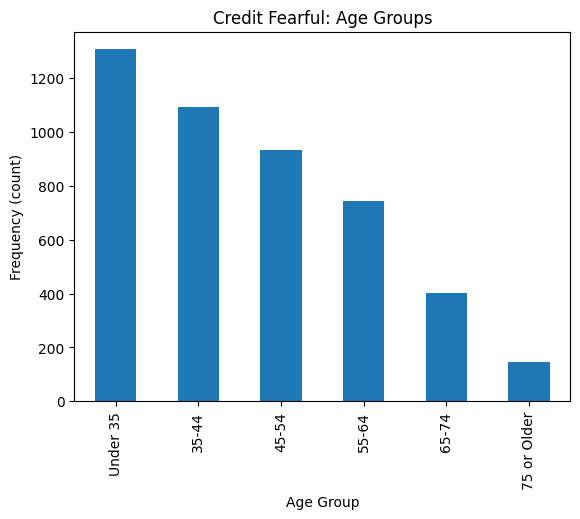

In [ ]:
age_cl_value_counts = age_cl.value_counts()

# Bar plot of `age_cl_value_counts`
age_cl_value_counts.plot(
     kind="bar",
     xlabel="Age Group",
     ylabel="Frequency (count)",
     title="Credit Fearful: Age Groups"
);

Our chart reveal that many of the people who fear being denied credit are younger. But the first two age groups cover a wider range than the other four. So it might be useful to look inside those values to get a more granular understanding of the data.

To do that, I'll need to look at a different variable: "AGE". Whereas "AGECL" was a categorical variable, "AGE" is continuous, so I can use it to make a histogram

## **Age**

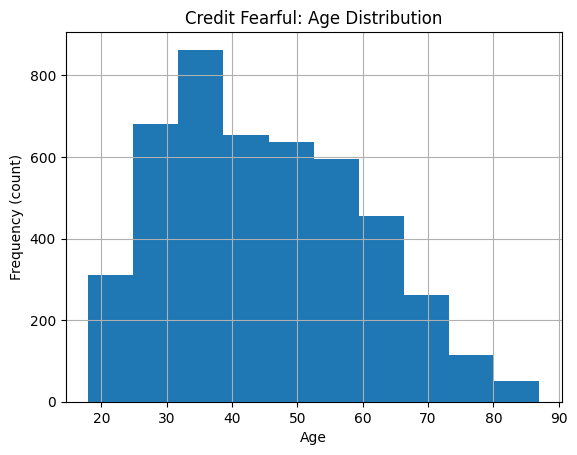

In [ ]:
# Plot histogram of "AGE"
df_fear["AGE"].hist(bins=10)
plt.xlabel("Age")
plt.ylabel("Frequency (count)")
plt.title("Credit Fearful: Age Distribution");

It looks like younger people are still more concerned about being able to secure a loan than older people, but the people who are most concerned seem to be between 30 and 40.

## **Race**

Now that we have an understanding of how age relates to our outcome of interest, let's try some other possibilities, starting with race

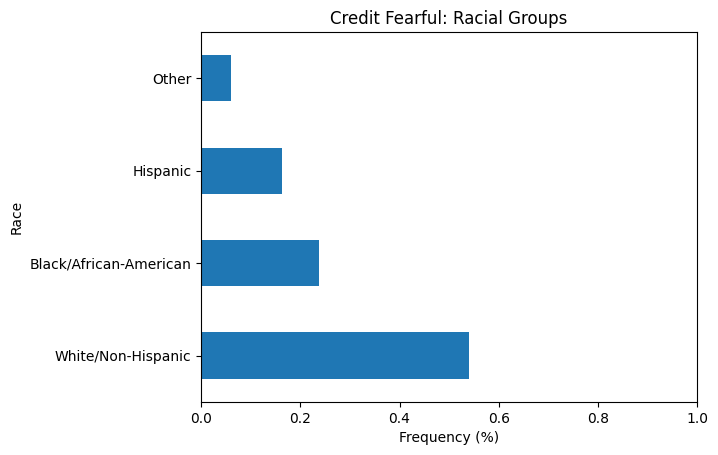

In [ ]:
race_dict = {
    1: "White/Non-Hispanic",
    2: "Black/African-American",
    3: "Hispanic",
    5: "Other",
}
race = df_fear["RACE"].replace(race_dict)
race_value_counts = race.value_counts(normalize=True)
# Create bar chart of race_value_counts
race_value_counts.plot(kind="barh")
plt.xlim((0, 1))
plt.xlabel("Frequency (%)")
plt.ylabel("Race")
plt.title("Credit Fearful: Racial Groups");

This suggests that White/Non-Hispanic people worry more about being denied credit, but thinking critically about what we're seeing, that might be because there are more White/Non-Hispanic in the population of the United States than there are other racial groups, and the sample for this survey was specifically drawn to be representative of the population as a whole.

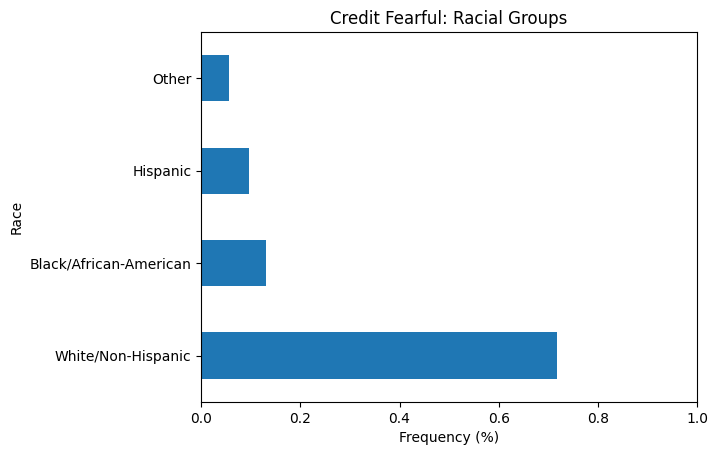

In [ ]:
race = df["RACE"].replace(race_dict)
race_value_counts = race.value_counts(normalize=True)
# Create bar chart of race_value_counts
race_value_counts.plot(kind="barh")
plt.xlim((0, 1))
plt.xlabel("Frequency (%)")
plt.ylabel("Race")
plt.title("Credit Fearful: Racial Groups");

This second bar chart change our perception of the first one? On the one hand, we can see that White Non-Hispanics account for around 70% of whole dataset, but only 54% of credit fearful respondents. On the other hand, Black and Hispanic respondents represent 23% of the whole dataset but 40% of credit fearful respondents. In other words, Black and Hispanic households are actually *more* likely to be in the credit fearful group.

# **Income**

What about income level? Are people with lower incomes concerned about being denied credit, or is that something people with more money worry about? In order to answer that question, we'll need to again compare the entire dataset with our subgroup using the "INCCAT" feature, which captures income percentile groups. This time, though, we'll make a single, side-by-side bar chart.

In [ ]:
inccat_dict = {
    1: "0-20",
    2: "21-39.9",
    3: "40-59.9",
    4: "60-79.9",
    5: "80-89.9",
    6: "90-100",
}

df_inccat = (
    df["INCCAT"]
    .replace(inccat_dict)
    .groupby(df["TURNFEAR"])
    .value_counts(normalize=True)
    .rename("frequency")
    .to_frame()
    .reset_index()
)

print("df_inccat type:", type(df_inccat))
print("df_inccat shape:", df_inccat.shape)
df_inccat

df_inccat type: <class 'pandas.core.frame.DataFrame'>
df_inccat shape: (12, 3)


,TURNFEAR,INCCAT,frequency
0,0,90-100,0.297296
1,0,60-79.9,0.174841
2,0,40-59.9,0.143146
3,0,0-20,0.140343
4,0,21-39.9,0.135933
5,0,80-89.9,0.108441
6,1,0-20,0.288125
7,1,21-39.9,0.256327
8,1,40-59.9,0.228856
9,1,60-79.9,0.132598


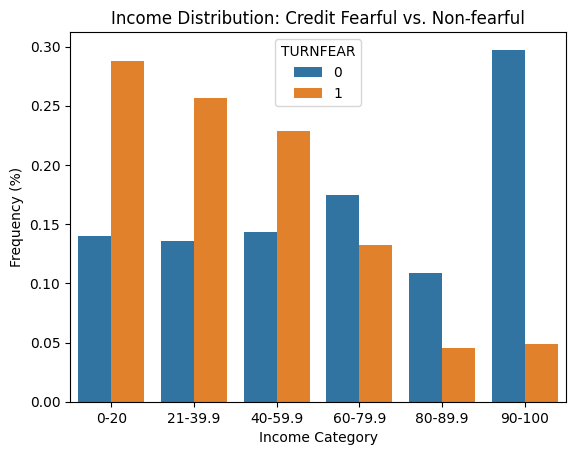

In [ ]:
# Create bar chart of `df_inccat`
sns.barplot(
    x="INCCAT",
    y="frequency",
    hue="TURNFEAR",
    data=df_inccat,
    order=inccat_dict.values()
)

plt.xlabel("Income Category")
plt.ylabel("Frequency (%)")
plt.title("Income Distribution: Credit Fearful vs. Non-fearful");

Comparing the income categories across the fearful and non-fearful groups, we can see that credit fearful households are much more common in the lower income categories. In other words, the credit fearful have lower incomes.

****Based on all this analysis, we uncover that among the people who responded that they were indeed worried about being approved for credit after having been denied in the past five years, a plurality of the young and low-income had the highest number of respondents. Young people tend to make less money and rely more heavily on credit to get their lives off the ground, so having been denied credit makes them more anxious about the future.****

## **Assets**

In [ ]:
#correlation coefficient for "ASSET" and "HOUSES"
asset_house_corr = df["ASSET"].corr(df["HOUSES"])
print("SCF: Asset Houses Correlation:", asset_house_corr)

SCF: Asset Houses Correlation: 0.5198273544779252


That's a moderate positive correlation

 What about the people in our **TURNFEAR** subset, Let's run that correlation to see if there's a difference

In [ ]:
asset_house_corr = df_fear["ASSET"].corr(df_fear["HOUSES"])
print("Credit Fearful: Asset Houses Correlation:", asset_house_corr)

Credit Fearful: Asset Houses Correlation: 0.583287973597916


Aha!! They're different. here is a moderate positive correlation, but the relationship between the total value of assets and the value of the primary residence is stronger for our **TURNFEAR** group than it is for the population as a whole.

Let's make correlation matrices using the rest of the data for both ***"df" and "df_fear"*** and see if the differences persist. I'll look at only 5 features: **"ASSET", "HOUSES", "INCOME", "DEBT", and "EDUC".**

In [ ]:
#correlation matrix with the whole DataFrame
cols = ["ASSET", "HOUSES", "INCOME", "DEBT", "EDUC"]
corr = df[cols].corr()
corr.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.519827,0.622429,0.261250,0.116673
HOUSES,0.519827,1.000000,0.247852,0.266661,0.169300
INCOME,0.622429,0.247852,1.000000,0.114646,0.069400
DEBT,0.261250,0.266661,0.114646,1.000000,0.054179
EDUC,0.116673,0.169300,0.069400,0.054179,1.000000


In [ ]:
#correlation matrix using df_fear
corr = df_fear[cols].corr()
corr.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.583288,0.722074,0.474658,0.113536
HOUSES,0.583288,1.000000,0.264099,0.962629,0.160348
INCOME,0.722074,0.264099,1.000000,0.172393,0.133170
DEBT,0.474658,0.962629,0.172393,1.000000,0.177386
EDUC,0.113536,0.160348,0.133170,0.177386,1.000000


Ohh! There are some pretty important differences here. The relationship between ***"DEBT" and "HOUSES"*** is positive for both datasets, but while the coefficient for ***df***  is fairly weak at 0.26, the same number for ***df_fear*** is 0.96

# **Eduction**

let's anaalyse education levels "EDUC", comparing credit fearful and non-credit fearful groups

In [ ]:
df_educ = (
    df["EDUC"]
    .groupby(df["TURNFEAR"])
    .value_counts(normalize=True)
    .rename("frequency")
    .to_frame()
    .reset_index()
)

print("df_educ type:", type(df_educ))
print("df_educ shape:", df_educ.shape)
df_educ.head()

df_educ type: <class 'pandas.core.frame.DataFrame'>
df_educ shape: (30, 3)


,TURNFEAR,EDUC,frequency
0,0,12,0.257481
1,0,8,0.192029
2,0,13,0.149823
3,0,9,0.129833
4,0,14,0.096117


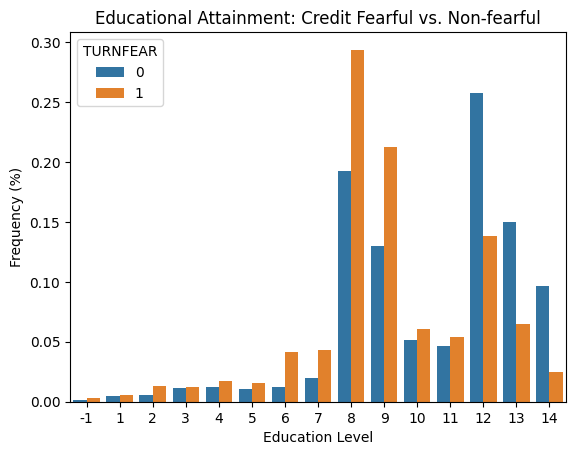

In [ ]:
# Create bar chart of `df_educ`
sns.barplot(
    x="EDUC",
    y="frequency",
    hue="TURNFEAR",
    data=df_educ
)
plt.xlabel("Education Level")
plt.ylabel("Frequency (%)")
plt.title("Educational Attainment: Credit Fearful vs. Non-fearful");

In this plot, we can see that a much higher proportion of credit-fearful respondents have only a high school diploma, while university degrees are more common among the non-credit fearful.

# **Debt**

Let's keep going with some scatter plots that look at debt.

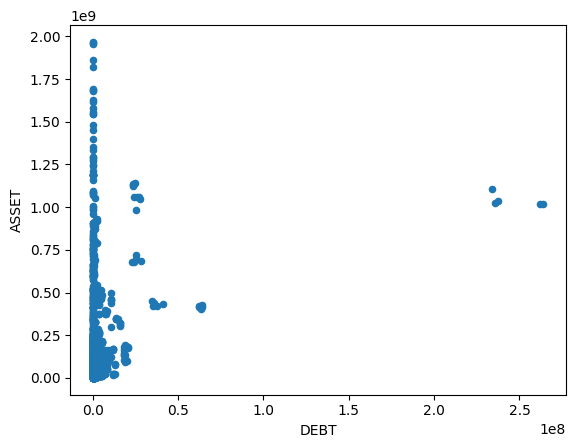

In [ ]:
# Create scatter plot of ASSET vs DEBT, df
df.plot.scatter(x="DEBT", y = "ASSET");

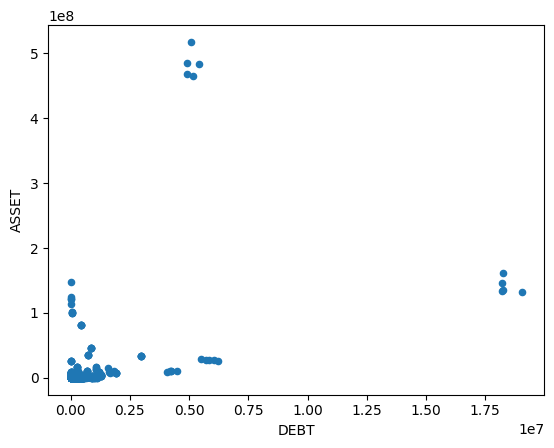

In [ ]:
# Create scatter plot of ASSET vs DEBT, df_fear
df_fear.plot.scatter(x="DEBT", y = "ASSET");

You can see relationship in our ***"df_fear"*** graph is flatter than the one in our ***"df"*** graph, but they clearly are different.

# **HOUSES and DEBT**

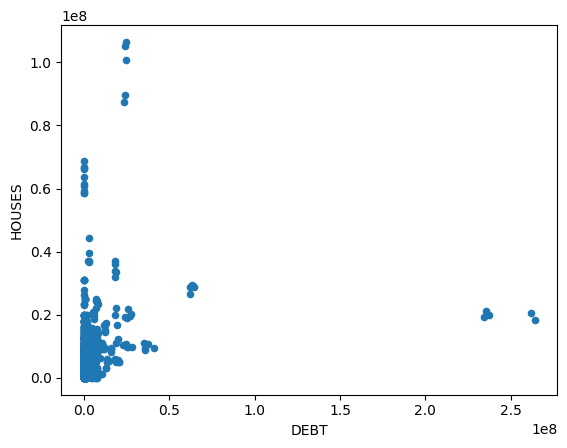

In [ ]:
# Create scatter plot of HOUSES vs DEBT, df
df.plot.scatter(x="DEBT", y = "HOUSES");

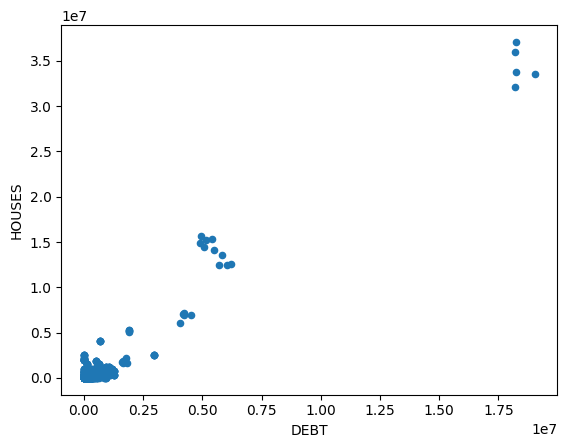

In [ ]:
# Create scatter plot of HOUSES vs DEBT, df_fear
df_fear.plot.scatter(x="DEBT", y = "HOUSES");

The outliers make it a little difficult to see the difference between these two plots, but the relationship is clear enough: The ***df_fear*** graph shows an almost perfect linear relationship, while our ***df*** graph shows something a little more muddled. I can also notice that the datapoints on the ***df_fear*** graph form several little clutters.

## **EDA Summarized**
**Let's discuss a little about our exploration data analysis EDA. First I took our dataset and found out that it has over 28,000 rows and 351 column.
To get my hands on the data, I subset it to a group that was only credit fearful. That's household that has been denied credit or fear been denied credit for the past five years. Then I began to explore the demographics of that subgroup. I analyse Age, race, education, income, asset and debt. Thanks to visualizations, I uncovered that education and income were lower for our credit fearful group than the non fearful group. I also looked at the correlation between those variables, then I discovered how housing value and amount of debt also different from those two groups. Lastly, I uncovered distinct clusters that I could use to segment our population. This uncovered will help to choose a right model.**

# **KMEANS MODEL**

## **Data transformation**

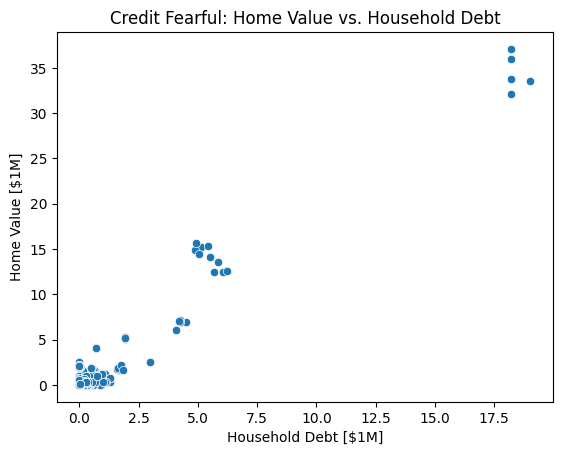

In [ ]:
# Plot "HOUSES" vs "DEBT", df_fear
sns.scatterplot(x=df_fear["DEBT"]/ 1e6, y=df_fear["HOUSES"]/ 1e6)
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt");

# **Data Preperation**

## **Split**

In [ ]:
X = df_fear[["DEBT", "HOUSES"]]

print("X type:", type(X))
print("X shape:", X.shape)
X.head()

X type: <class 'pandas.core.frame.DataFrame'>
X shape: (4623, 2)


,DEBT,HOUSES
5,12200.0,0.0
6,12600.0,0.0
7,15300.0,0.0
8,14100.0,0.0
9,15400.0,0.0


# **Build Model**

## **Iterate**

In [ ]:
# Build model
model = KMeans(n_clusters=3, random_state=42)
print("model type:", type(model))

# Fit model to data
model.fit(X)

model type: <class 'sklearn.cluster._kmeans.KMeans'>


KMeans(n_clusters=3, random_state=42)

In [ ]:
labels = model.labels_
print("labels type:", type(labels))
print("labels shape:", labels.shape)
labels[:10]

labels type: <class 'numpy.ndarray'>
labels shape: (4623,)


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

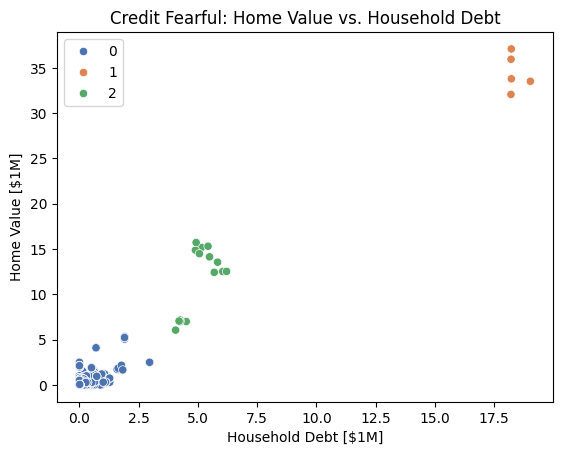

In [ ]:
# Plot "HOUSES" vs "DEBT" with hue=label
sns.scatterplot(
    x=df_fear["DEBT"]/ 1e6,
    y=df_fear["HOUSES"]/ 1e6,
    hue=labels,
    palette= "deep"
)

plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt");
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt");

In [ ]:
centroids = model.cluster_centers_
print("centroids type:", type(centroids))
print("centroids shape:", centroids.shape)
centroids

centroids type: <class 'numpy.ndarray'>
centroids shape: (3, 2)


array([[   91017.57766674,   116150.29328698],
       [18384100.        , 34484000.        ],
       [ 5065800.        , 11666666.66666667]])

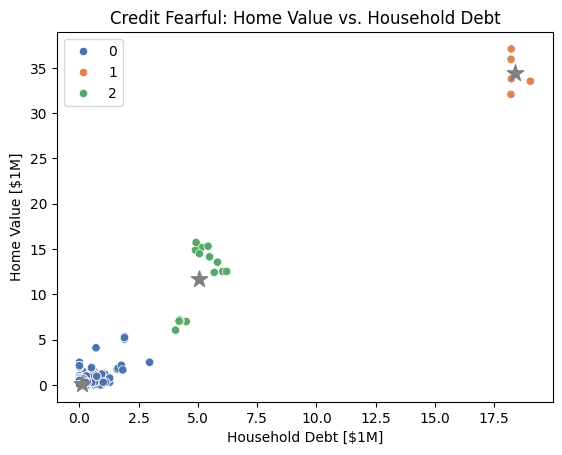

In [ ]:
# Plot "HOUSES" vs "DEBT", add centroids
sns.scatterplot(
    x=df_fear["DEBT"]/ 1e6,
    y=df_fear["HOUSES"]/ 1e6,
    hue=labels,
    palette= "deep"
)
plt.scatter(
    x=centroids[:, 0] / 1e6,
    y=centroids[:, 1] / 1e6,
    color= "gray",
    marker = "*",
    s = 150
)
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt");

### **Let's proceed with numerical evaluation.**

***Inertia score***

In [ ]:
inertia = model.inertia_
print("inertia type:", type(inertia))
print("Inertia (3 clusters):", inertia)

inertia type: <class 'float'>
Inertia (3 clusters): 939554010797059.4


***silhouette_score***

In [ ]:
ss = silhouette_score(X, model.labels_)
print("ss type:", type(ss))
print("Silhouette Score (3 clusters):", ss)

ss type: <class 'numpy.float64'>
Silhouette Score (3 clusters): 0.9768842462944348


### **To determine the best K**

 I will use a ***for loop*** to build and train a K-Means model where ***n_clusters*** ranges from 2 to 12 (inclusive). Each time a model is trained, calculate the inertia and add it to the list ***inertia_errors***, then calculate the silhouette score and add it to the list ***silhouette_scores***.

In [ ]:
n_clusters = range(2,13)
inertia_errors = []
silhouette_scores = []

# Add `for` loop to train model and calculate inertia, silhouette score.
for k in n_clusters:
    #build model
    model = KMeans(n_clusters=k, random_state=42)
    #train model
    model.fit(X)
    #calculate inertia
    inertia_errors.append(model.inertia_)
    #calculate ss
    silhouette_scores.append(silhouette_score(X, model.labels_))


print("inertia_errors type:", type(inertia_errors))
print("inertia_errors len:", len(inertia_errors))
print("Inertia:", inertia_errors)
print()
print("silhouette_scores type:", type(silhouette_scores))
print("silhouette_scores len:", len(silhouette_scores))
print("Silhouette Scores:", silhouette_scores)

inertia_errors type: <class 'list'>
inertia_errors len: 11
Inertia: [3018038313336857.5, 939554010797059.4, 546098841715646.25, 312953826439188.7, 259345573699051.2, 190276466219404.72, 182823496442980.5, 137854230409642.14, 101281028664355.22, 94456305764354.53, 82784036332859.89]

silhouette_scores type: <class 'list'>
silhouette_scores len: 11
Silhouette Scores: [np.float64(0.9855099957519555), np.float64(0.9768842462944348), np.float64(0.9490311483406091), np.float64(0.8145735206135484), np.float64(0.8098677144717595), np.float64(0.7283895532760676), np.float64(0.7292682050725934), np.float64(0.7303424143073027), np.float64(0.733219368089596), np.float64(0.7338888149535772), np.float64(0.7323568183281238)]


Now that I have both performance metrics for several different settings of ***n_clusters***, let's make some line plots to see the relationship between the number of clusters in a model and its inertia and silhouette scores.

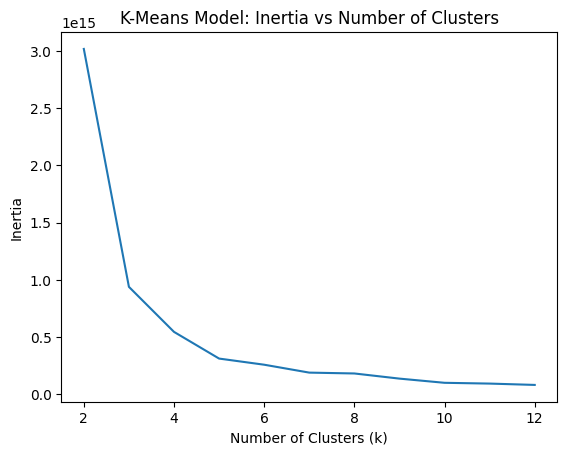

In [ ]:
# Plot `inertia_errors` by `n_clusters`
plt.plot(n_clusters, inertia_errors)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Model: Inertia vs Number of Clusters");

What we're seeing here is that, as the number of clusters increases, inertia goes down.

The trick with choosing the right number of clusters is to look for the "bend in the elbow" for this plot. In other words, we want to pick the point where the drop in inertia becomes less dramatic and the line begins to flatten out. In this case, it looks like the sweet spot is 4 or 5.

**Let's see what the silhouette score looks like.**

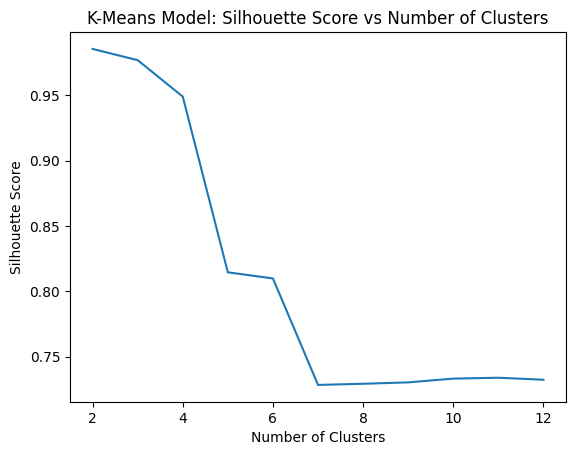

In [ ]:
# Plot `silhouette_scores` vs `n_clusters`
plt.plot(n_clusters, silhouette_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Model: Silhouette Score vs Number of Clusters");

In contrast to our inertia plot, bigger is better for silhouette score. So we're not looking for a "bend in the elbow" but rather a number of clusters for which the silhouette score still remains high. We can see that silhouette score drops drastically beyond 4 clusters. Given this and what we saw in the inertia plot, it looks like the optimal number of clusters is 4.

***Now that we've decided on the final number of clusters, let's build a final model.***

In [ ]:
# Build model
final_model = KMeans(n_clusters=4, random_state=42)
print("model type:", type(model))

# Fit model to data
final_model.fit(X)

model type: <class 'sklearn.cluster._kmeans.KMeans'>


KMeans(n_clusters=4, random_state=42)

## **Communicate**

In [ ]:
centroids = final_model.cluster_centers_
print("centroids type:", type(centroids))
print("centroids shape:", centroids.shape)
centroids

centroids type: <class 'numpy.ndarray'>
centroids shape: (4, 2)


array([[   84886.28951384,   103187.22476563],
       [18384100.        , 34484000.        ],
       [ 2420928.57142857,  4551428.57142857],
       [ 5472800.        , 14074000.        ]])

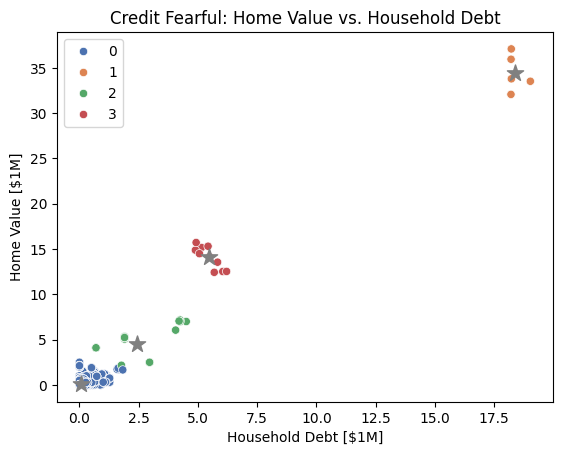

In [ ]:
# Plot "HOUSES" vs "DEBT" with final_model labels
sns.scatterplot(
    x=df_fear["DEBT"]/ 1e6,
    y=df_fear["HOUSES"]/ 1e6,
    hue=final_model.labels_,
    palette= "deep"
)
plt.scatter(
    x=centroids[:, 0] / 1e6,
    y=centroids[:, 1] / 1e6,
    color= "gray",
    marker = "*",
    s = 150
)
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt");


let's create a DataFrame xgb that contains the mean "DEBT" and "HOUSES" values for each of the clusters in your final_model

In [ ]:
xgb = X.groupby(final_model.labels_).mean()

print("xgb type:", type(xgb))
print("xgb shape:", xgb.shape)
xgb

xgb type: <class 'pandas.core.frame.DataFrame'>
xgb shape: (4, 2)


,DEBT,HOUSES
0,8.488629e+04,1.031872e+05
1,1.838410e+07,3.448400e+07
2,2.420929e+06,4.551429e+06
3,5.472800e+06,1.407400e+07


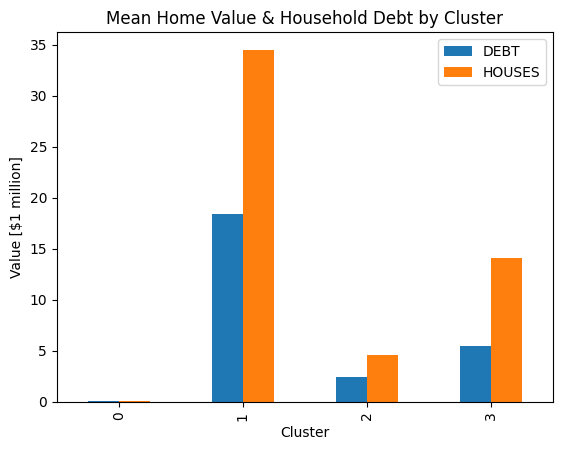

In [ ]:
# Create side-by-side bar chart of `xgb`
(xgb /1e6).plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Value [$1 million]")
plt.title("Mean Home Value & Household Debt by Cluster");

In this plot, we have our four clusters spread across the x-axis, and the dollar amounts for home value and household debt on the y-axis.

The first thing to look at in this chart is the different mean home values for the five clusters. Clusters 0 represents households with small to moderate home values, clusters 2 and 3 have high home values, and cluster 1 has extremely high values.

The second thing to look at is the proportion of debt to home value. In clusters 1 and 2, this proportion is around 0.5. This suggests that these groups have a moderate amount of untapped equity in their homes. But for group 0, it's almost 1, which suggests that the largest source of household debt is their mortgage. Group 3 is unique in that they have the smallest proportion of debt to home value, around 0.4.

This information could be useful to financial institution that want to target customers with products that would appeal to them. For instance, households in group 0 might be interested in refinancing their mortgage to lower their interest rate. Group 3 households could be interested in a home equity line of credit because they have more equity in their homes. And the bankers, Bill Gates, and Beyoncés in group 1 might want white-glove personalized wealth management.

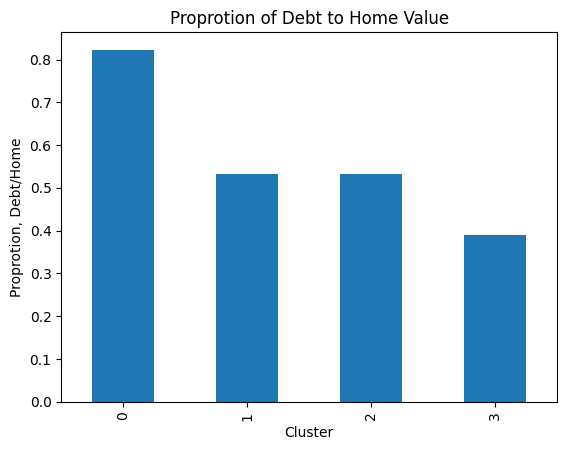

In [ ]:
(xgb["DEBT"] / xgb["HOUSES"]).plot(
    kind="bar",
    xlabel= "Cluster",
    ylabel= "Proprotion, Debt/Home",
    title=  "Proprotion of Debt to Home Value",
);

## **KMeans clustering summarized**

**This model is focused on credit fearful household. Those household that has been denied credit or fear been denied credit. I explore the relationship between debt and home features. I then proceed to build an unsupervised leanings "KMean". This helps to devide this household into groups, by looking at metrics such as inertia and silhouette score I were able to decide the optimum numbers of cluster to be 4 which lead to the final model. I proceed with visualization not just a scatter plot but also a side by side bar chart which helps decide the mean characteristics of each group, that's the mean debt and mean household value and this gives the interpretation power to distinct each groups.**

**In the next model I will look at more features because in this model I only consider "debt and home values"**

# **MULTIPLE FEATURES (KMEANS MODEL)**

Use a DataFrame of households whose net worth is less than $2 million and that have been turned down for credit or feared being denied credit in the past 5 years (see "TURNFEAR").

In [ ]:
mask = (df["TURNFEAR"] == 1) & (df["NETWORTH"] < 2_000_000)
df_fear = df[mask]
print("df_fear type:", type(df_fear))
print("df_fear shape:", df_fear.shape)
df_fear.head()

df_fear type: <class 'pandas.core.frame.DataFrame'>
df_fear shape: (4418, 351)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
5,2,21,3790.476607,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
6,2,22,3798.868505,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,3,2,2
7,2,23,3799.468393,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
8,2,24,3788.076005,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
9,2,25,3793.066589,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2


## **Data Exploration**

I want to make clusters using more than two features, but which of the 351 features should I choose? One of the best way to choose the best features for clustering is to determine which numerical features have the largest variance. That's what I'll do here.

In [ ]:
# Calculate variance, get 10 largest features
top_ten_var = df_fear.var().sort_values().tail(10)

print("top_ten_var type:", type(top_ten_var))
print("top_ten_var shape:", top_ten_var.shape)
top_ten_var

top_ten_var type: <class 'pandas.core.series.Series'>
top_ten_var shape: (10,)


,0
PLOAN1,1.140894e+10
ACTBUS,1.251892e+10
BUS,1.256643e+10
KGTOTAL,1.346475e+10
DEBT,1.848252e+10
NHNFIN,2.254163e+10
HOUSES,2.388459e+10
NETWORTH,4.847029e+10
NFIN,5.713939e+10
ASSET,8.303967e+10


In [ ]:
# Create horizontal bar chart of `top_ten_var`
fig = px.bar(
    x= top_ten_var,
    y= top_ten_var.index,
    title= "SCF: High Variance Features"
)
fig.update_layout(xaxis_title="Variance", yaxis_title="Feature")
fig.show()

One thing that I've notice throughout this project is that many of the wealth indicators are highly skewed, with a few outlier households having enormous wealth. Those outliers can affect our measure of variance. Let's see if that's the case with one of the features from top_five_var

In [ ]:
# Create a boxplot of `NHNFIN`
fig = px.box(
    data_frame=df_fear,
    x= "NHNFIN",
    title= "Distribution of Non-home, Non-Financial Assets"
)
fig.update_layout(xaxis_title="Value [$]")
fig.show()

The dataset is massively right-skewed because of the huge outliers on the right side of the distribution. Even though I already excluded households with a high net worth with the "mask" function, the variance is still being distorted by some extreme outliers.

The best way to deal with this is to look at the **trimmed variance**, where I remove extreme values before calculating variance. This can be achieve using the "trimmed_variance" function from the "SciPy" library.

In [ ]:
# Calculate trimmed variance
top_ten_trim_var = df_fear.apply(trimmed_var, limits=(0.1, 0.1)).sort_values().tail(10)

print("top_ten_trim_var type:", type(top_ten_trim_var))
print("top_ten_trim_var shape:", top_ten_trim_var.shape)
top_ten_trim_var

top_ten_trim_var type: <class 'pandas.core.series.Series'>
top_ten_trim_var shape: (10,)


,0
WAGEINC,5.550737e+08
HOMEEQ,7.338377e+08
NH_MORT,1.333125e+09
MRTHEL,1.380468e+09
PLOAN1,1.441968e+09
DEBT,3.089865e+09
NETWORTH,3.099929e+09
HOUSES,4.978660e+09
NFIN,8.456442e+09
ASSET,1.175370e+10


In [ ]:
# Create horizontal bar chart of `top_ten_trim_var`
fig = px.bar(
    x= top_ten_trim_var,
    y= top_ten_trim_var.index,
    title= "SCF: High Variance Features"
)
fig.update_layout(xaxis_title="Trimmed Variance", yaxis_title="Feature")
fig.show()

There are three things I notice in this plot. First, the variances have decreased a lot. In our previous chart, the x-axis went up to \$80 billion; this one goes up to \$12 billion. Second, the top 10 features have changed a bit. All the features relating to business ownership ("...BUS") are gone. Finally, I can see that there are big differences in variance from feature to feature. For example, the variance for "WAGEINC" is around than \$500 million, while the variance for "ASSET" is nearly \$12 billion. In other words, these features have completely different scales. This is something that I'll need to address before I can make good clusters.

In [ ]:
high_var_cols = top_ten_trim_var.tail(5).index.to_list()

print("high_var_cols type:", type(high_var_cols))
print("high_var_cols len:", len(top_ten_trim_var))
high_var_cols

high_var_cols type: <class 'list'>
high_var_cols len: 10


['DEBT', 'NETWORTH', 'HOUSES', 'NFIN', 'ASSET']

## **Split**

In [ ]:
X = df_fear[high_var_cols]

print("X type:", type(X))
print("X shape:", X.shape)
X.head()

X type: <class 'pandas.core.frame.DataFrame'>
X shape: (4418, 5)


,DEBT,NETWORTH,HOUSES,NFIN,ASSET
5,12200.0,-6710.0,0.0,3900.0,5490.0
6,12600.0,-4710.0,0.0,6300.0,7890.0
7,15300.0,-8115.0,0.0,5600.0,7185.0
8,14100.0,-2510.0,0.0,10000.0,11590.0
9,15400.0,-5715.0,0.0,8100.0,9685.0


# **Build Model**

## **Iterate**

During EDA, I saw that I had a scale issue among features. That issue can make it harder to cluster the data, so I'll need to fix that to help my analysis. One strategy I can use is **standardization**, a statistical method for putting all the variables in a dataset on the same scale. Let's see how that works. Later, I'll incorporate it into the model pipeline.

In [ ]:
X_summary = X.aggregate(["mean", "std"]).astype(int)

print("X_summary type:", type(X_summary))
print("X_summary shape:", X_summary.shape)
X_summary

X_summary type: <class 'pandas.core.frame.DataFrame'>
X_summary shape: (2, 5)


,DEBT,NETWORTH,HOUSES,NFIN,ASSET
mean,72701,76387,74530,117330,149089
std,135950,220159,154546,239038,288166


In [ ]:
# Instantiate transformer
ss = StandardScaler()

# Transform `X`
X_scaled_data = ss.fit_transform(X)

# Put `X_scaled_data` into DataFrame
X_scaled = pd.DataFrame(X_scaled_data, columns=X.columns)

print("X_scaled type:", type(X_scaled))
print("X_scaled shape:", X_scaled.shape)
X_scaled.head()

X_scaled type: <class 'pandas.core.frame.DataFrame'>
X_scaled shape: (4418, 5)


,DEBT,NETWORTH,HOUSES,NFIN,ASSET
0,-0.445075,-0.377486,-0.48231,-0.474583,-0.498377
1,-0.442132,-0.368401,-0.48231,-0.464541,-0.490047
2,-0.422270,-0.383868,-0.48231,-0.467470,-0.492494
3,-0.431097,-0.358407,-0.48231,-0.449061,-0.477206
4,-0.421534,-0.372966,-0.48231,-0.457010,-0.483818


Great, all five of the features now use the same scale. For authentification, let me take a look at their mean and standard deviation.

In [ ]:
X_scaled_summary =  X_scaled.aggregate(["mean", "std"]).astype(int)

print("X_scaled_summary type:", type(X_scaled_summary))
print("X_scaled_summary shape:", X_scaled_summary.shape)
X_scaled_summary

X_scaled_summary type: <class 'pandas.core.frame.DataFrame'>
X_scaled_summary shape: (2, 5)


,DEBT,NETWORTH,HOUSES,NFIN,ASSET
mean,0,0,0,0,0
std,1,1,1,1,1


That's what it should look like

In [ ]:
n_clusters = range(2, 13)
inertia_errors = []
silhouette_scores = []

# Add `for` loop to train model and calculate inertia, silhouette score.
for k in n_clusters:
    #build model
    model = make_pipeline(StandardScaler(), KMeans(n_clusters=k, random_state=42))
    #train model
    model.fit(X)
    #calculate inertia
    inertia_errors.append(model.named_steps["kmeans"].inertia_)
    #calculate ss
    silhouette_scores.append(
        silhouette_score(X, model.named_steps["kmeans"].labels_)
    )

print("inertia_errors type:", type(inertia_errors))
print("inertia_errors len:", len(inertia_errors))
print("Inertia:", inertia_errors)
print()
print("silhouette_scores type:", type(silhouette_scores))
print("silhouette_scores len:", len(silhouette_scores))
print("Silhouette Scores:", silhouette_scores)

inertia_errors type: <class 'list'>
inertia_errors len: 11
Inertia: [11028.058082607145, 7190.703769068722, 6233.106346879283, 5009.683910188741, 4935.578599045232, 4282.331488864108, 4103.658567417201, 3503.1098972163163, 2874.961491201993, 2646.094394137888, 2505.4713082029007]

silhouette_scores type: <class 'list'>
silhouette_scores len: 11
Silhouette Scores: [np.float64(0.7464502937083215), np.float64(0.7042841259119152), np.float64(0.7046977054481021), np.float64(0.6563064140490201), np.float64(0.6589817231149715), np.float64(0.6414988659227319), np.float64(0.6423235394675234), np.float64(0.6453132882450023), np.float64(0.6392046929708322), np.float64(0.6214410819897591), np.float64(0.6237975162108229)]


**Just like last model, let's create an elbow plot to see how many clusters we should use.**

In [ ]:
# Create line plot of `inertia_errors` vs `n_clusters`
fig = px.line(
    x= n_clusters, y= inertia_errors, title= "K-Means Model: Inertia vs Number of Clusters"
)
fig.update_layout(xaxis_title= "Number of Clusters (k)", yaxis_title= "Inertia")

fig.show()

The line starts to flatten out around 4 or 5 clusters

In [ ]:
# Create a line plot of `silhouette_scores` vs `n_clusters`
fig = px.line(
    x= n_clusters,
    y= silhouette_scores,
    title= "K-Means Model: Silhouette Score vs Number of Clusters"
)
fig.update_layout(xaxis_title= "Number of Clusters (k)", yaxis_title= "Silhouette Score")
fig.show()

This one's a little less straightforward, but I can see that the best silhouette scores occur when there are 3 or 4 clusters.

Putting the information from this plot together with inertia plot, it seems like the best setting for ***n_clusters*** will be 4.

# **Build model**

In [ ]:
# Build model
final_model = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=4, random_state=42)
)

# Fit model to data
final_model.fit(X)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=4, random_state=42))])

# **Communicate**

In [ ]:
labels = final_model.named_steps["kmeans"].labels_

print("labels type:", type(labels))
print("labels len:", len(labels))
print(labels[:5])

labels type: <class 'numpy.ndarray'>
labels len: 4418
[1 1 1 1 1]


In [ ]:
xgb = X.groupby(labels).mean()

print("xgb type:", type(xgb))
print("xgb shape:", xgb.shape)
xgb

xgb type: <class 'pandas.core.frame.DataFrame'>
xgb shape: (4, 5)


,DEBT,NETWORTH,HOUSES,NFIN,ASSET
0,205111.440049,2.314333e+05,261927.688504,3.512653e+05,4.365447e+05
1,28650.810927,1.176536e+04,14647.482838,2.825256e+04,4.041617e+04
2,669360.967742,5.819507e+05,788306.451613,1.118355e+06,1.251312e+06
3,266576.274510,1.432137e+06,339117.647059,1.295769e+06,1.698713e+06


In [ ]:
# Create side-by-side bar chart of `xgb`
fig = px.bar(
    xgb,
    barmode="group",
    title="Mean Household Finances by Cluster"
)
fig.update_layout(xaxis_title="Cluster", yaxis_title="Value [$]")
fig.show()

Looking at the mean values for each cluster, I can see some clear distinctions between the groups. Cluster 1 represents households with the lowest mean values across all features (DEBT, NETWORTH, HOUSES, NFIN, ASSET). Cluster 0 has slightly higher mean values than cluster 1, particularly in NETWORTH and HOUSES. Cluster 2 shows significantly higher mean values for all features compared to clusters 0 and 1, and notably has the highest mean NETWORTH. Cluster 3 has the highest mean values for DEBT, NFIN, and ASSET, and the second highest mean NETWORTH and HOUSES.

Specifically, observing the relationship between **DEBT** and **HOUSES**, cluster 1 has a higher mean **DEBT** than **HOUSES**, suggesting that debt might be primarily from mortgages or other non-housing related sources. In contrast, clusters 0, 2, and 3 all have higher mean **HOUSES** values than **DEBT**, indicating that these groups hold more equity in their homes.

These distinctions suggest that the clusters represent different financial profiles among credit-fearful households. Cluster 1 could be characterized as having limited financial resources, while clusters 0, 2, and 3 represent increasing levels of wealth and asset ownership. These insights could be valuable for targeted financial product development or support programs.

In [ ]:
# Instantiate transformer
pca = PCA(n_components=2, random_state=42)

# Transform `X`
X_t = pca.fit_transform(X)

# Put `X_t` into DataFrame
X_pca = pd.DataFrame(X_t, columns=["PC1","PC2"])

print("X_pca type:", type(X_pca))
print("X_pca shape:", X_pca.shape)
X_pca.head()

X_pca type: <class 'pandas.core.frame.DataFrame'>
X_pca shape: (4418, 2)


,PC1,PC2
0,-221525.424530,22052.273003
1,-217775.100722,22851.358068
2,-219519.642175,19023.646333
3,-212195.720367,22957.107039
4,-215540.507551,20259.749306


In [ ]:
# Create scatter plot of `PC2` vs `PC1`
fig = px.scatter(
    data_frame=X_pca,
    x="PC1",
    y="PC2",
    color=labels.astype(str),
    title="PCA Representation of Clusters"
)
fig.update_layout(xaxis_title="PC1", yaxis_title="PC2")
fig.show()

This scatter plot visualizes the four clusters in a 2-dimensional space after applying Principal Component Analysis (PCA) to the original five features **DEBT, NETWORTH, HOUSES, NFIN, and ASSET**. PCA reduces the dimensionality of the data while retaining as much of the original variance as possible. In this plot:

*   Each point represents a household from the **df_fear** dataset.
*   The position of each point is determined by its scores on the first two principal components (PC1 and PC2). These components are linear combinations of the original features and capture the most significant patterns of variation in the data.
*   The color of each point indicates the cluster assigned by the K-Means model.

Observing the plot, I can see that the clusters are generally separated in this reduced dimension space, which indicates that the KMeans model was able to identify distinct groupings based on the chosen financial features. Cluster 1 (purple) appears to be the most distinct group, occupying a separate region on the left side of the plot. The other clusters (0, 2, and 3) show some overlap, particularly between clusters 0 (blue) and 3 (green), but there are still discernible patterns of separation. This visualization helps to confirm that the clusters are meaningful and provides a visual representation of how the different financial profiles identified in the bar chart are distributed in the data.

## **Multiple features summarize**

I had a 351 features and I know that I want to create a model with more than two features but I dont know which features to used.
In order to decide, I calculated a variance and a trimmed variance of each feature and ended up with five best feature i thought it will be good for my model.
I proceeded with a model building, which i used an unsupervised machine learning with a two pieces history. First, the standard scaller which took the features from different scale and change it to a mean of 1 and a standard diviation of 0 and I incorporate it in a pipeline with a "KMeans estimator" and I did an hyperparameter tunning and found out with an initia and ss that the best number of clussters was 4.
After that, i build a final_model with 4 clustters and extract an information from the model, I looked at the mean characteristics of each group with a side by side bar chart and uncovered a distinct information between each group.
finaly, I had a five dimension, and i went on to put them in a two dimension using PCA to create a scatter plot.

#  **WEB APP**

In [ ]:
mask = (df["TURNFEAR"] == 1) & (df["NETWORTH"] < 2_000_000)
df_fear = df[mask]
print("df_fear type:", type(df_fear))
print("df_fear shape:", df_fear.shape)
df_fear.head()

df_fear type: <class 'pandas.core.frame.DataFrame'>
df_fear shape: (4418, 351)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
5,2,21,3790.476607,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
6,2,22,3798.868505,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,3,2,2
7,2,23,3799.468393,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
8,2,24,3788.076005,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
9,2,25,3793.066589,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2


In [ ]:
app = Dash(__name__)

print("app type:", type(app))

app type: <class 'dash.dash.Dash'>


In [ ]:
### get_high_var_features()

In [ ]:
def get_high_var_features(trimmed=True, return_feat_names=True):
    """Returns the five highest-variance features of ``df``.

    Parameters
    ----------
    trimmed : bool, default=True
        If ``True``, calculates trimmed variance, removing bottom and top 10%
        of observations.

    return_feat_names : bool, default=False
        If ``True``, returns feature names as a ``list``. If ``False``
        returns ``Series``, where index is feature names and values are
        variances.
    """
    # Calculate variance
    if trimmed:
        top_five_features=(
            df_fear.apply(trimmed_var).sort_values().tail(5)
        )
    else:
         top_five_features= df_fear.var().sort_values().tail(5)
    #Extract names
    if return_feat_names:
        top_five_features = top_five_features.index.tolist()

    return top_five_features

In [ ]:
#decorator
@app.callback(
    Output("bar-chart", "figure"), Input("trim-button", "value")
)
def serve_bar_chart(trimmed=True):
    """Returns a horizontal bar chart of five highest-variance features.

    Parameters
    ----------
    trimmed : bool, default=True
        If ``True``, calculates trimmed variance, removing bottom and top 10%
        of observations.
    """
    #get features
    top_five_features = get_high_var_features(trimmed=trimmed, return_feat_names=False)
    #Build barchart
    fig = px.bar(x=top_five_features, y=top_five_features.index, orientation="h")
    fig.update_layout(xaxis_title="Variance", yaxis_title="Features")


    return fig

In [ ]:
### serve_bar_chart(trimmed=True)

In [ ]:
#decorator
#@app.callback(
 #   Output("bar-chart", "figure"), Input("trim-button", "value")
#)

In [ ]:
def get_model_metrics(trimmed=True, k=2, return_metrics=False):
    """Build ``KMeans`` model based on five highest-variance features in ``df``.

    Parameters
    ----------
    trimmed : bool, default=True
        If ``True``, calculates trimmed variance, removing bottom and top 10%
        of observations.

    k : int, default=2
        Number of clusters.

    return_metrics : bool, default=False
        If ``False`` returns ``KMeans`` model. If ``True`` returns ``dict``
        with inertia and silhouette score.

    """
    #Get high var features
    features= get_high_var_features(trimmed=trimmed, return_feat_names=True)
    X = df_fear[features]
    #build model
    model= make_pipeline(StandardScaler(),KMeans(n_clusters=k, random_state=42))
    # Fit model to data
    model.fit(X)
    if return_metrics:
        #calculate inertia
        i = model.named_steps["kmeans"].inertia_
        #calculate silhouette score
        ss= silhouette_score(X, model.named_steps["kmeans"].labels_)
        # Put result into dictionary
        metrics= {
            "inertia": round(i),
            "silhouette": round(ss, 3)
        }
        # Return dictionary to users
        return metrics

    return model

In [ ]:
get_model_metrics(trimmed=True, k=3, return_metrics=True)

{'inertia': 7191, 'silhouette': np.float64(0.704)}

In [ ]:
get_model_metrics(trimmed=True, k=2, return_metrics=False)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=2, random_state=42))])

In [ ]:
#decorator
@app.callback(
    Output("metrics", "children"),
    Input("trim-button", "value"),
    Input("k-slider", "value")
)

def serve_metrics(trimmed=True, k=2):
    """Returns list of ``H3`` elements containing inertia and silhouette score
    for ``KMeans`` model.

    Parameters
    ----------
    trimmed : bool, default=True
        If ``True``, calculates trimmed variance, removing bottom and top 10%
        of observations.

    k : int, default=2
        Number of clusters.
    """
    # Get metrics
    metrics = get_model_metrics(trimmed=trimmed, k=k, return_metrics = True)
    # Add metrics to HTML elements
    text = [
        html.H3(f"Inertia: {metrics['inertia']}"),
        html.H3(f"Silhouette Score: {metrics ['silhouette']}")
    ]
    return text

In [ ]:
serve_metrics()

[H3('Inertia: 11028'), H3('Silhouette Score: 0.746')]

In [ ]:
def get_pca_labels(trimmed=True, k=2):
    """
    ``KMeans`` labels.

    Parameters
    ----------
    trimmed : bool, default=True
        If ``True``, calculates trimmed variance, removing bottom and top 10%
        of observations.

    k : int, default=2
        Number of clusters.
    """
    # Create feature matrix
    features = get_high_var_features(trimmed=trimmed, return_feat_names=True)
    X= df_fear[features]

    #Buiid transformer
    transformer = PCA(n_components=2, random_state=42)
    # Transform data
    X_t = transformer.fit_transform(X)
    X_pca = pd.DataFrame(X_t, columns=["PC1", "PC2"])
    # Add labels
    model = get_model_metrics(trimmed=trimmed, k=k, return_metrics=False)
    X_pca["labels"] = model.named_steps["kmeans"].labels_.astype(str)
    X_pca.sort_values("labels", inplace=True)

    return X_pca

In [ ]:
@app.callback(
    Output("pca-scatter", "figure"),
    Input("trim-button", "value"),
    Input("k-slider", "value")
)

def serve_scatter_plot(trimmed=True, k=2):
    """Build 2D scatter plot of ``df`` with ``KMeans`` labels.

    Parameters
    ----------
    trimmed : bool, default=True
        If ``True``, calculates trimmed variance, removing bottom and top 10%
        of observations.

    k : int, default=2
        Number of clusters.
    """
    fig= px.scatter(
        data_frame=get_pca_labels(trimmed=trimmed, k=k),
        x="PC1",
        y="PC2",
        color="labels",
        title= "PCA Representation of Cluster"
    )
    fig.update_layout(xaxis_title="PC1", yaxis_title="PC2")
    return fig

In [ ]:
app.layout = html.Div(
    [
        # Application title
        html.H1("Survey of Consumer Finances"),
        # Bar chart element
        html.H2("High Variance Features"),
        # bar-chart (place_holder graph)
        dcc.Graph(figure = serve_bar_chart(), id="bar-chart"),
        # Radio botton
        dcc.RadioItems(
            options=[
                {"label": "trimmed", "value": True},
                {"label": "not trimmed", "value": False}
            ],
            value=True,
            id="trim-button"
        ),
        # Kmeans slider
        html.H2("K-means Clustering"),
        html.H3("Number of Clusters (k)"),
        dcc.Slider(min=2, max=12, step=1, value=2, id="k-slider"),
        # metrix placeholder
        html.Div(id="metrics"),
        # PCA scatter plot "placeholder"
        dcc.Graph(id="pca-scatter")
    ]
)

In [ ]:

app.run(host="0.0.0.0", port=8050)

<IPython.core.display.Javascript object>

## **Web App Summarized**

I proceed to buind my web app and web application layout usin a jupyter dash, I added an HTML and a dash call component element.
I used a three-layer architecture; the presntation, business and data layer. I design a three element; barchart, slider and a scattr plot under the presentation layer,
the business layer manages how data is transformed or processed before being displayed. the data layer responsible for data retrieval, storage & machine learning models.

In this project I work on unsupervised machine learning which i specialized on Clustering. I ended with an amazing web application